# Transfer Learning

For this project we are going to use <code>EfficientNet_B3_Weights.IMAGENET1K_V1</code> pretrained model for detecting the *brain tumor*. It's a pretty fine model with good accuracy and less number of parameters.

## 0. Setting up

Let's get starting by importing / downloading important libraries/modules for this project

In [2]:
"""# For this notebook to run with updated APIs, we need torch 1.12+ and torchvision 0.13+
try:
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu113
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")"""

'# For this notebook to run with updated APIs, we need torch 1.12+ and torchvision 0.13+\ntry:\n    import torch\n    import torchvision\n    print(f"torch version: {torch.__version__}")\n    print(f"torchvision version: {torchvision.__version__}")\nexcept:\n    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")\n    !pip3 install -U torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu113\n    import torch\n    import torchvision\n    print(f"torch version: {torch.__version__}")\n    print(f"torchvision version: {torchvision.__version__}")'

In [3]:
# Continue with regular imports
import torch
import torchvision
import matplotlib.pyplot as plt

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

import going_modular.data_setup as data_setup
import going_modular.engine as engine



In [4]:
# Setting up the device agnostic code
device= "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 1. Creating Datasets and DataLoaders

Before creating the <code>Datasets</code> and <code>DataLoaders</code> we need to setup the <code>transform</code> for the images.
When a pretrained model like <code>EfficientNet_B3_Weights.IMAGENET1K_V1</code> then image is need to be pre-processed so that will be ready to use by the <code>data_setup.py</code> to make <code>Datasets</code> and <code>DataLoaders</code>.

### 1.1 Creating a transform for <code>torchvision.models</code>

For a pre-trained model we can directly automate the transform that we need by setting up by it's pre-trained weights. As shown below

In [5]:
# Get a set of pre-trained model weights
weights=torchvision.models.EfficientNet_B3_Weights.DEFAULT
weights

EfficientNet_B3_Weights.IMAGENET1K_V1

In [6]:
# Getting the transform for the pretrained model weights
"""B3_transforms=weights.transforms()
B3_transforms"""
from torchvision import transforms
from torchvision.transforms import InterpolationMode
import torch

# Enhanced transform for MRI JPG images
mri_transforms = transforms.Compose([
    transforms.Resize(320, interpolation=InterpolationMode.BICUBIC),  # Match EfficientNet-B3 resize
    transforms.CenterCrop(300),
    # Add more augmentation techniques
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),  # Randomly rotate by up to 15 degrees
    transforms.RandomAffine(
        degrees=0,  # No additional rotation
        translate=(0.1, 0.1),  # Shift image by up to 10% horizontally/vertically
        scale=(0.9, 1.1),  # Random scaling between 90-110%
        fill=0
    ),
    # Adjust brightness, contrast, saturation (use carefully with MRI)
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    # Optional: Gaussian blur can help with noise/artifacts in medical images
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Standard normalization
])

# For validation, use minimal transforms (no augmentation)
val_transforms = transforms.Compose([
    transforms.Resize(320, interpolation=InterpolationMode.BICUBIC), 
    transforms.CenterCrop(300),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [42]:
# Creating training and testing DataLoaders as well as get a list of class_names
train_dataloaders, class_names=data_setup.create_train_dataloaders(train_dir="brain tumor\\train_90p",
                                                                               transform=mri_transforms,
                                                                               batch_size=32)


test_dataloaders=data_setup.create_test_dataloaders(test_dir="brain tumor\\test_10p",
                                                    transform=val_transforms,
                                                    batch_size=32)

class_names

['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

## 2. Getting a pretrained model

### 2.1 Setting up a pretrained model

In [8]:
# Setup the model with pre-trained weights and send the model to the device
weights=torchvision.models.EfficientNet_B3_Weights.DEFAULT
model=torchvision.models.efficientnet_b3(weights=weights).to(device)
model


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
            (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActiv

### 2.2 Getting a summary of our model with <code>torchinfo.summary()</code>

In [9]:
summary(model=model, 
        input_size=(32, 3, 224, 224), # make sure this is "input_size", not "input_shape"
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 1000]           --                   True
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1536, 7, 7]     --                   True
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 40, 112, 112]   --                   True
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 40, 112, 112]   1,080                True
│    │    └─BatchNorm2d (1)                                  [32, 40, 112, 112]   [32, 40, 112, 112]   80                   True
│    │    └─SiLU (2)                                         [32, 40, 112, 112]   [32, 40, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 40, 112, 112]   [32, 24, 112

### 2.3 Freezing the base model and changing the output layer 

In [10]:
# Freezing all the base layers
for param in model.features.parameters():
    param.requires_grad=False


# Get the length of the class_names
output_shape=len(class_names)

model.classifier=torch.nn.Sequential(
    torch.nn.Dropout(p=0.2,inplace=True),
    torch.nn.Linear(in_features=1536,out_features=output_shape,bias=True).to(device)
)


In [11]:
summary(model, 
        input_size=(32, 3, 224, 224), # make sure this is "input_size", not "input_shape" (batch_size, color_channels, height, width)
        verbose=0,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 4]              --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1536, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 40, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 40, 112, 112]   (1,080)              False
│    │    └─BatchNorm2d (1)                                  [32, 40, 112, 112]   [32, 40, 112, 112]   (80)                 False
│    │    └─SiLU (2)                                         [32, 40, 112, 112]   [32, 40, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 40, 112, 112]   [32, 

## 3. Train a model

To begin training I am going to set a <code>Loss function</code> and an <code>optimizer</code>

In [12]:
# Define loss function and optimizer
loss_fn=torch.nn.modules.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

In [ ]:
# Start the timer
# Windows-specific fix for DataLoader
import torch.multiprocessing
torch.multiprocessing.set_sharing_strategy('file_system')
from timeit import default_timer as timer 
start_time=timer()

# setup training using engine.py

results=engine.train(model=model,
                     train_dataloader=train_dataloaders,
                     test_dataloader=test_dataloaders,
                     loss_fn=loss_fn,
                     optimizer=optimizer,
                     epochs=8,
                     device=device)

end_time=timer()

print(f"Total time taken is {end_time-start_time:.4f}")


'# Start the timer\n# Windows-specific fix for DataLoader\nimport torch.multiprocessing\ntorch.multiprocessing.set_sharing_strategy(\'file_system\')\nfrom timeit import default_timer as timer \nstart_time=timer()\n\n# setup training using engine.py\n\nresults=engine.train(model=model,\n                     train_dataloader=train_dataloaders,\n                     test_dataloader=test_dataloaders,\n                     loss_fn=loss_fn,\n                     optimizer=optimizer,\n                     epochs=8,\n                     device=device)\n\nend_time=timer()\n\nprint(f"Total time taken is {end_time-start_time:.4f}")\n'

## 4. Plotting the curves

In [ ]:
# Get the plot_loss_curves() function from helper_functions.py, download the file if we don't have it
try:
    from helper_functions import plot_loss_curves
except:
    print("[INFO] Couldn't find helper_functions.py, downloading...")
    with open("helper_functions.py", "wb") as f:
        import requests
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
        f.write(request.content)
    from helper_functions import plot_loss_curves

# Plot the loss curves of our model
plot_loss_curves(results)

'# Get the plot_loss_curves() function from helper_functions.py, download the file if we don\'t have it\ntry:\n    from helper_functions import plot_loss_curves\nexcept:\n    print("[INFO] Couldn\'t find helper_functions.py, downloading...")\n    with open("helper_functions.py", "wb") as f:\n        import requests\n        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")\n        f.write(request.content)\n    from helper_functions import plot_loss_curves\n\n# Plot the loss curves of our model\nplot_loss_curves(results)'

## 5. Saving the model

In [ ]:
import going_modular.utils_save_3 as utils_save_3

In [ ]:
utils_save_3.save_model(model,target_dir="models",model_name="Eff_net_b3_01_brain_tumor.pth")

'utils_save_3.save_model(model,target_dir="models",model_name="Eff_net_b3_01_brain_tumor.pth")'

## Testing on custom images

In [17]:
from typing import List, Tuple
from torchvision import transforms
from torchvision.transforms import InterpolationMode

from PIL import Image

# 1. Take in a trained model, class names, image path, image size, a transform and target device
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str, 
                        class_names: List[str],
                        image_size: Tuple[int, int] = (224, 224),
                        transform: torchvision.transforms = None,
                        device: torch.device=device):
    
    
    # 2. Open image
    img = Image.open(image_path)

    # 3. Create transformation for image (if one doesn't exist)
    if transform is not None:
        image_transform = transform
    else:
        image_transform = transforms.Compose([
        transforms.Resize(320, interpolation=InterpolationMode.BICUBIC),
        transforms.CenterCrop(300),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
        ])

    ### Predict on image ### 

    # 4. Make sure the model is on the target device
    model.to(device)

    # 5. Turn on model evaluation mode and inference mode
    model.eval()
    with torch.inference_mode():
      # 6. Transform and add an extra dimension to image (model requires samples in [batch_size, color_channels, height, width])
      transformed_image = image_transform(img).unsqueeze(dim=0)

      # 7. Make a prediction on image with an extra dimension and send it to the target device
      target_image_pred = model(transformed_image.to(device))

    # 8. Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

    # 9. Convert prediction probabilities -> prediction labels
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    # 10. Plot image with predicted label and probability 
    plt.figure()
    plt.imshow(img)
    plt.title(f"Pred: {class_names[target_image_pred_label]} | Prob: {target_image_pred_probs.max():.3f}")
    plt.axis(False);

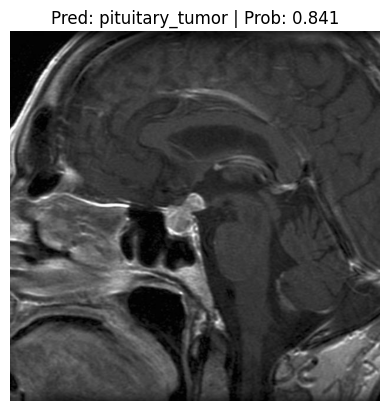

In [26]:
import torch
from torchvision import models

# 1. Define the model architecture (same as used during training)
from torchvision.models import efficientnet_b3

# Make sure the number of output classes matches your trained model
model = efficientnet_b3(weights=None)
model.classifier[1] = torch.nn.Linear(in_features=1536, out_features=len(class_names))

# 2. Load the trained weights
model.load_state_dict(torch.load("G:\\My Drive\\01 Projects\\01. Brain tumor\\models\\Eff_net_b3_01_brain_tumor.pth", map_location=torch.device("cuda" if torch.cuda.is_available() else "cpu")))

# 3. Predict
pred_and_plot_image(model=model,
                    image_path="pitutary_2.jpg",
                    class_names=class_names)
